# Placebo-in-time and falsification: a UK CO₂ case study

## What does it mean to "find an effect"?

When a model reports an effect whose credible interval excludes zero, most analysts exhale.  The intervention worked.  Ship the slide deck.

But excluding zero is a statement about **parameter uncertainty**: the noise *inside* the model.  It tells you that, *conditional on the model being correct*, the data are unlikely to have been generated by a zero effect.  That conditional clause does most of the heavy lifting, and it is almost never true.

Every quasi-experimental method rests on identifying assumptions: parallel trends, no anticipation, no interference. When those assumptions crack, and they always crack a little, the model's counterfactual drifts from truth.  [Bugaev & Trujillo (2026)](https://github.com/cetagostini/placebo-in-time-quasi-experiment/blob/main/pdf/paper.pdf) call this gap the **structural error**: the systematic deviation between what the model promises and what reality delivers. Standard credible intervals are blind to it.

Gallea puts the epistemological point sharply:

> *"We cannot prove causality with a simple test [...] the most important assumption, called the unconfoundedness assumption, is usually not testable.  We can only assess how plausible the assumption is."*  --- Gallea (2026)

So we cannot *prove* that a policy worked.  What we can do is behave like **causal detectives**, accumulate evidence from multiple angles, stress-test our estimator, and ask whether the story holds together. Each piece of evidence is small. The argument is the pile.

This notebook demonstrates the full detective workflow on a real policy question, using [CausalPy](https://causalpy.readthedocs.io).

In particular, this notebook showcases the **placebo-in-time** check: a way to stress-test the identifying assumptions of an ITS model by re-fitting it on pre-intervention dates where we *know* nothing happened. The spread of those false-positive 'effects' becomes a calibrated null distribution. The actual post-intervention effect only counts as evidence if it lives clearly outside that null. Used together with falsification on related outcomes, this is how you move from "the credible interval excludes zero" to a causal claim you can defend to yourself, to a colleague, and to a skeptical stakeholder.

:::{.callout-tip}
### What you will be able to do by the end

- Run a **placebo-in-time** check that asks your estimator what it reports when nothing happened.
- Read the resulting null distribution as a calibrated picture of structural error, not just sampling noise.
- Combine that calibration with **falsification** on related outcomes, the detective's other tool, to build a causal claim that survives a skeptical reader.

We will work the question on a real policy: the UK's 2013 Carbon Price Floor. The four questions we ask of it are the four questions you should ask of any quasi-experimental result that crosses your desk.
:::

## The case: the UK's 2013 Carbon Price Floor

In April 2013, the UK introduced the **Carbon Price Floor (CPF)**, a top-up tax on carbon emissions from electricity generation.  The EU's Emissions Trading System was supposed to make dirty power expensive, but the carbon price had collapsed to around EUR 5/tonne. The CPF set a floor well above that, deliberately designed to make coal power unprofitable relative to gas and renewables.

**The causal question:** Did the Carbon Price Floor reduce coal CO₂ ~ emissions in the UK?

We will answer this in four steps, each one small and honest:

| Step | Question | What we learn |
|:-----|:---------|:--------------|
| **1. Estimate** | Did coal CO₂ drop after 2013? | The size and direction of the change |
| **2. Calibrate** | How often does this model produce false positives? | Whether we should trust the estimator at all |
| **3. Trace the mechanism** | If coal died, where did the energy go? | Whether the substitution story is consistent |
| **4. Check the boundary** | Did total CO₂ or energy demand change? | Whether something *else* explains the result |

No single step is conclusive.  Together, they build a case.

## Setup


In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import causalpy as cp

%config InlineBackend.figure_format = 'retina'
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/CausalPy/lib/python3.13/site-packages/pymc_extras/model/marginal/graph_analysis.py:10: FutureWarning: `pytensor.graph.basic.io_toposort` was moved to `pytensor.graph.traversal.io_toposort`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import io_toposort


## The data

We combine two open datasets from **Our World in Data**: annual CO₂ emissions and energy generation by source.  We focus on the UK from 1990 to 2018: 23 years before the policy and 5 after.

In [ ]:
# NOTE: This notebook fetches data at runtime from Our World in Data's
# public S3 buckets (nyc3.digitaloceanspaces.com). If those URLs change
# or become unreachable the cell below will fail; mirror the CSVs
# locally and point CO2_URL / ENERGY_URL at them if that happens.
CO2_URL = "https://nyc3.digitaloceanspaces.com/owid-public/data/co2/owid-co2-data.csv"
ENERGY_URL = (
    "https://nyc3.digitaloceanspaces.com/owid-public/data/energy/owid-energy-data.csv"
)

MIN_YEAR = 1990
MAX_YEAR = 2018

# --- CO2 data ---
df_co2 = pd.read_csv(CO2_URL)
df_co2 = df_co2[
    (df_co2["country"] == "United Kingdom")
    & (df_co2["year"] >= MIN_YEAR)
    & (df_co2["year"] <= MAX_YEAR)
].copy()

# --- Energy data ---
df_energy = pd.read_csv(ENERGY_URL)
df_energy = df_energy[
    (df_energy["country"] == "United Kingdom")
    & (df_energy["year"] >= MIN_YEAR)
    & (df_energy["year"] <= MAX_YEAR)
][["year", "coal_electricity"]].copy()

# Merge on year
df_uk = df_co2.merge(df_energy, on="year", how="left")

# ITS needs a DatetimeIndex
df_uk["date"] = pd.to_datetime(df_uk["year"], format="%Y")
df_uk = df_uk.set_index("date").sort_index()

treatment_time = pd.to_datetime("2013-01-01")

print(f"UK observations: {len(df_uk)}")
print(f"Years: {df_uk['year'].min()} – {df_uk['year'].max()}")
print(f"Treatment: {treatment_time.year}")
print(f"Pre-treatment: {len(df_uk.loc[: treatment_time - pd.Timedelta(days=1)])} years")
print(f"Post-treatment: {len(df_uk.loc[treatment_time:])} years")

UK observations: 29
Years: 1990 – 2018
Treatment: 2013
Pre-treatment: 23 years
Post-treatment: 6 years


,year,co2,coal_co2,coal_electricity,energy_per_gdp
date,,,,,
1990-01-01,1990,601.945,252.690,206.44,1.666
1991-01-01,1991,609.413,253.623,211.46,1.721
1992-01-01,1992,593.846,237.747,193.64,1.706
1993-01-01,1993,579.613,207.686,171.25,1.686
1994-01-01,1994,574.017,195.376,161.34,1.605
1995-01-01,1995,566.159,181.699,155.21,1.572
1996-01-01,1996,586.761,173.072,147.27,1.609
1997-01-01,1997,562.708,154.729,121.97,1.535
1998-01-01,1998,568.544,154.088,122.97,1.501


## Looking at the data

Before fitting anything, look.  Patterns you can see with your eyes are more robust than patterns that require a model to reveal.

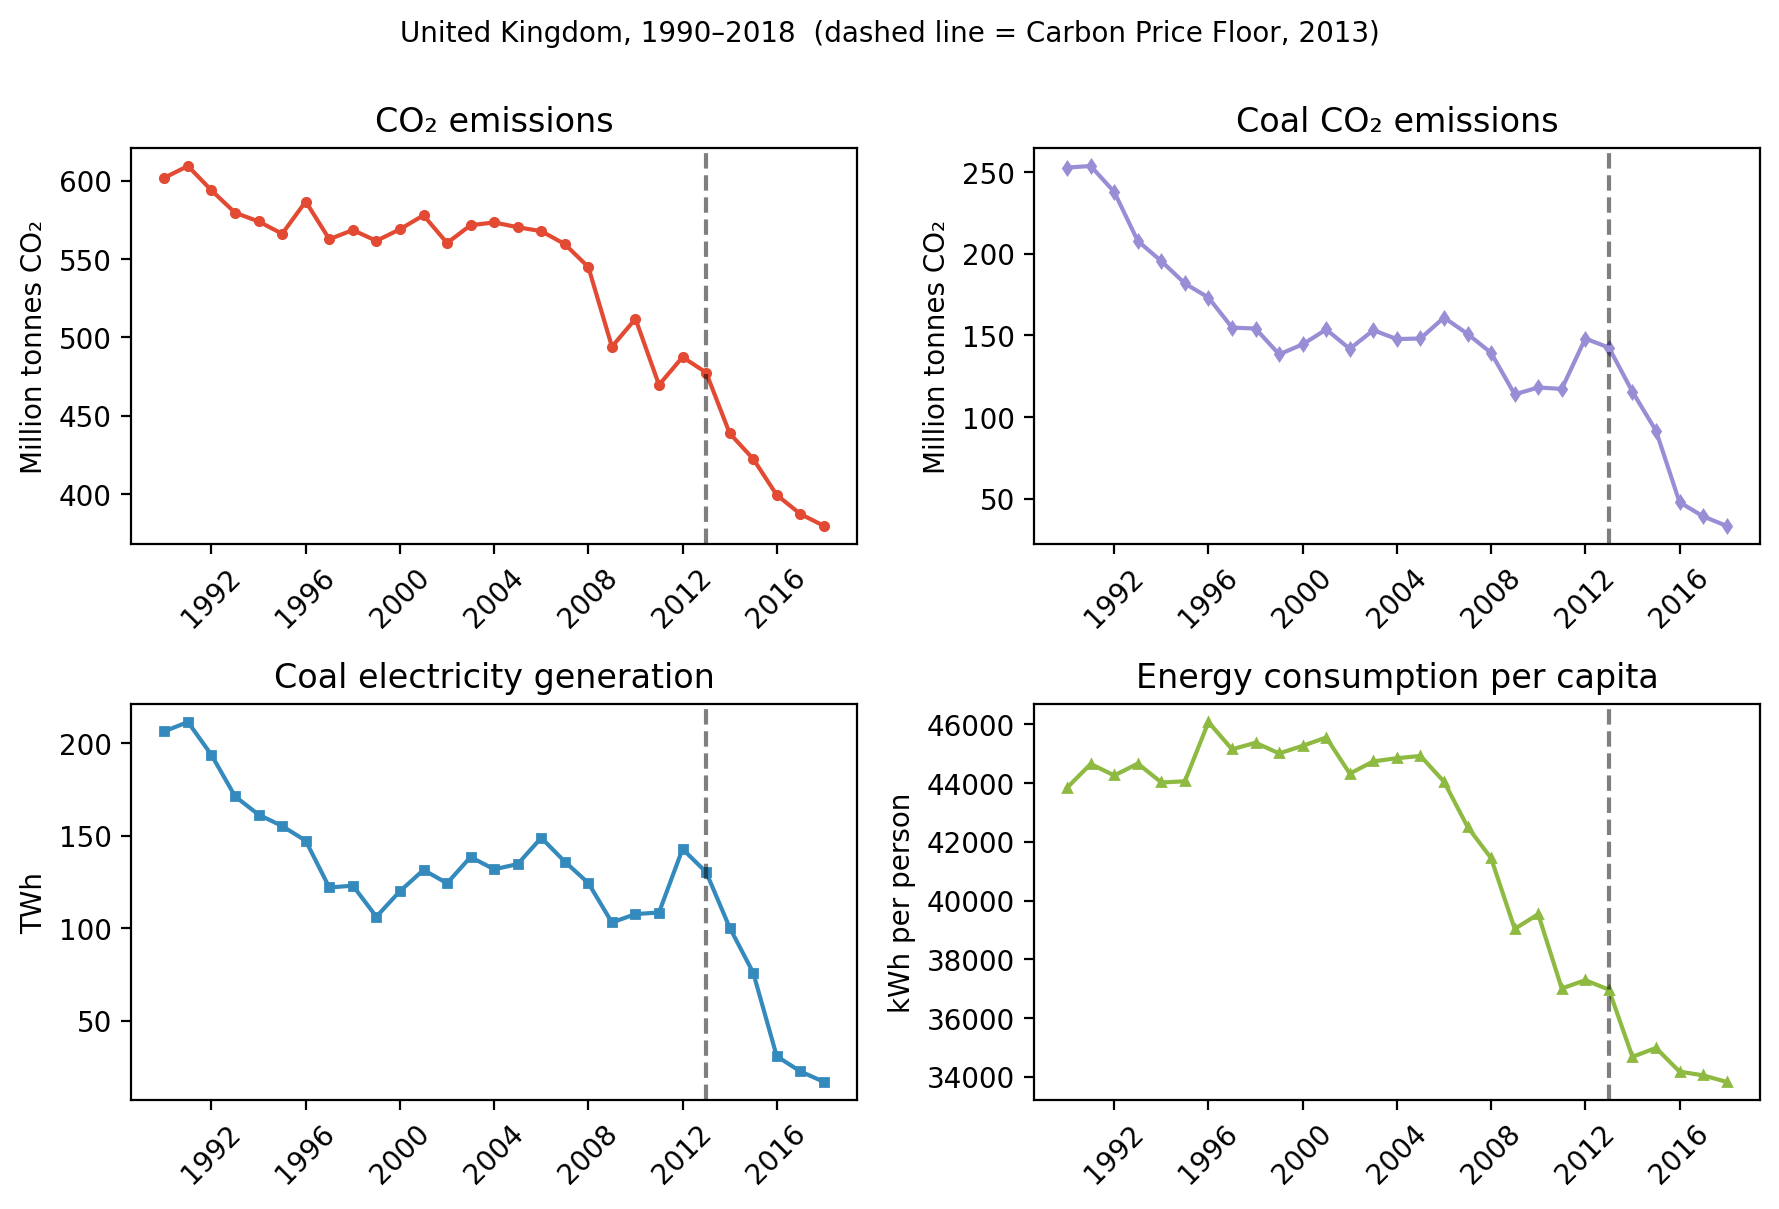

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# CO2
ax = axes[0, 0]
ax.plot(df_uk.index, df_uk["co2"], "o-", color="#E24A33", lw=1.5, ms=3)
ax.axvline(treatment_time, ls="--", color="k", alpha=0.5)
ax.set_ylabel("Million tonnes CO₂")
ax.set_title("CO₂ emissions")

# Coal CO2
ax = axes[0, 1]
ax.plot(df_uk.index, df_uk["coal_co2"], "d-", color="#988ED5", lw=1.5, ms=3)
ax.axvline(treatment_time, ls="--", color="k", alpha=0.5)
ax.set_ylabel("Million tonnes CO₂")
ax.set_title("Coal CO₂ emissions")

# Coal electricity
ax = axes[1, 0]
ax.plot(df_uk.index, df_uk["coal_electricity"], "s-", color="#348ABD", lw=1.5, ms=3)
ax.axvline(treatment_time, ls="--", color="k", alpha=0.5)
ax.set_ylabel("TWh")
ax.set_title("Coal electricity generation")

# Energy per capita
ax = axes[1, 1]
ax.plot(df_uk.index, df_uk["energy_per_capita"], "^-", color="#8EBA42", lw=1.5, ms=3)
ax.axvline(treatment_time, ls="--", color="k", alpha=0.5)
ax.set_ylabel("kWh per person")
ax.set_title("Energy consumption per capita")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(
    "United Kingdom, 1990–2018  (dashed line = Carbon Price Floor, 2013)",
    fontsize=10,
    y=1.00,
)
fig.tight_layout()
plt.show()

Four series, one dashed line. Coal CO₂ ~ and coal electricity show a visible break after 2013. Total CO₂ declines more gently. Energy per capita drifts down throughout, with no obvious discontinuity.

These are eyeball impressions. Now, we need a model.

## Question 1: Estimate the effect on coal CO₂

### Why coal CO₂?

The Carbon Price Floor was a tax on **electricity generation from fossil fuels**.  Its direct, first-order target was coal. If we want the sharpest test of whether the policy worked, we should measure the outcome closest to the mechanism: **coal CO₂ emissions**.

Total CO₂ is tempting because it is the ultimate goal, but it mixes the policy's direct effect with dozens of other forces (transport, industry, heating).  Starting with the sharpest outcome gives us the strongest signal-to-noise ratio.

### The model

We use CausalPy's `BayesianBasisExpansionTimeSeries`, a flexible Bayesian model that captures nonlinear trends via basis functions and changepoints. It fits the pre-treatment data and projects forward; the gap between projection and reality is the estimated effect.

:::{.callout-note}
### A note on reproducibility

We fix `random_seed=42` on both the sampler and every `PlaceboInTime(...)` call below. The placebo check selects fold dates randomly, and even a small change in which pre-period years it picks can move the printed $p_{\text{cal}}$ by several percentage points. Pinning both seeds keeps the prose, the printed verdicts, the calibration plot, and the power curve all consistent with each other on every re-render.
:::

In [ ]:
sampler_kwargs = {
    "target_accept": 0.91,
    "step_scale": 0.48,
    "max_treedepth": 110,
    "chains": 4,
    "draws": 400,
    "cores": 8,
    "random_seed": 42,
}


def its_model():
    """Fresh BayesianBasisExpansionTimeSeries model (single-use)."""
    return cp.pymc_models.BayesianBasisExpansionTimeSeries(
        n_order=4,
        n_changepoints_trend=8,
        prior_sigma=0.05,
        sample_kwargs=sampler_kwargs,
    )

In [ ]:
result_coal_co2 = cp.InterruptedTimeSeries(
    data=df_uk[["coal_co2"]],
    treatment_time=treatment_time,
    formula="coal_co2 ~ 1",
    model=its_model(),
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 400 draw iterations (4_000 + 1_600 draws total) took 44 seconds.
Sampling: [beta, delta, fourier_beta, sigma, y_hat]
Sampling: [y_hat]


Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


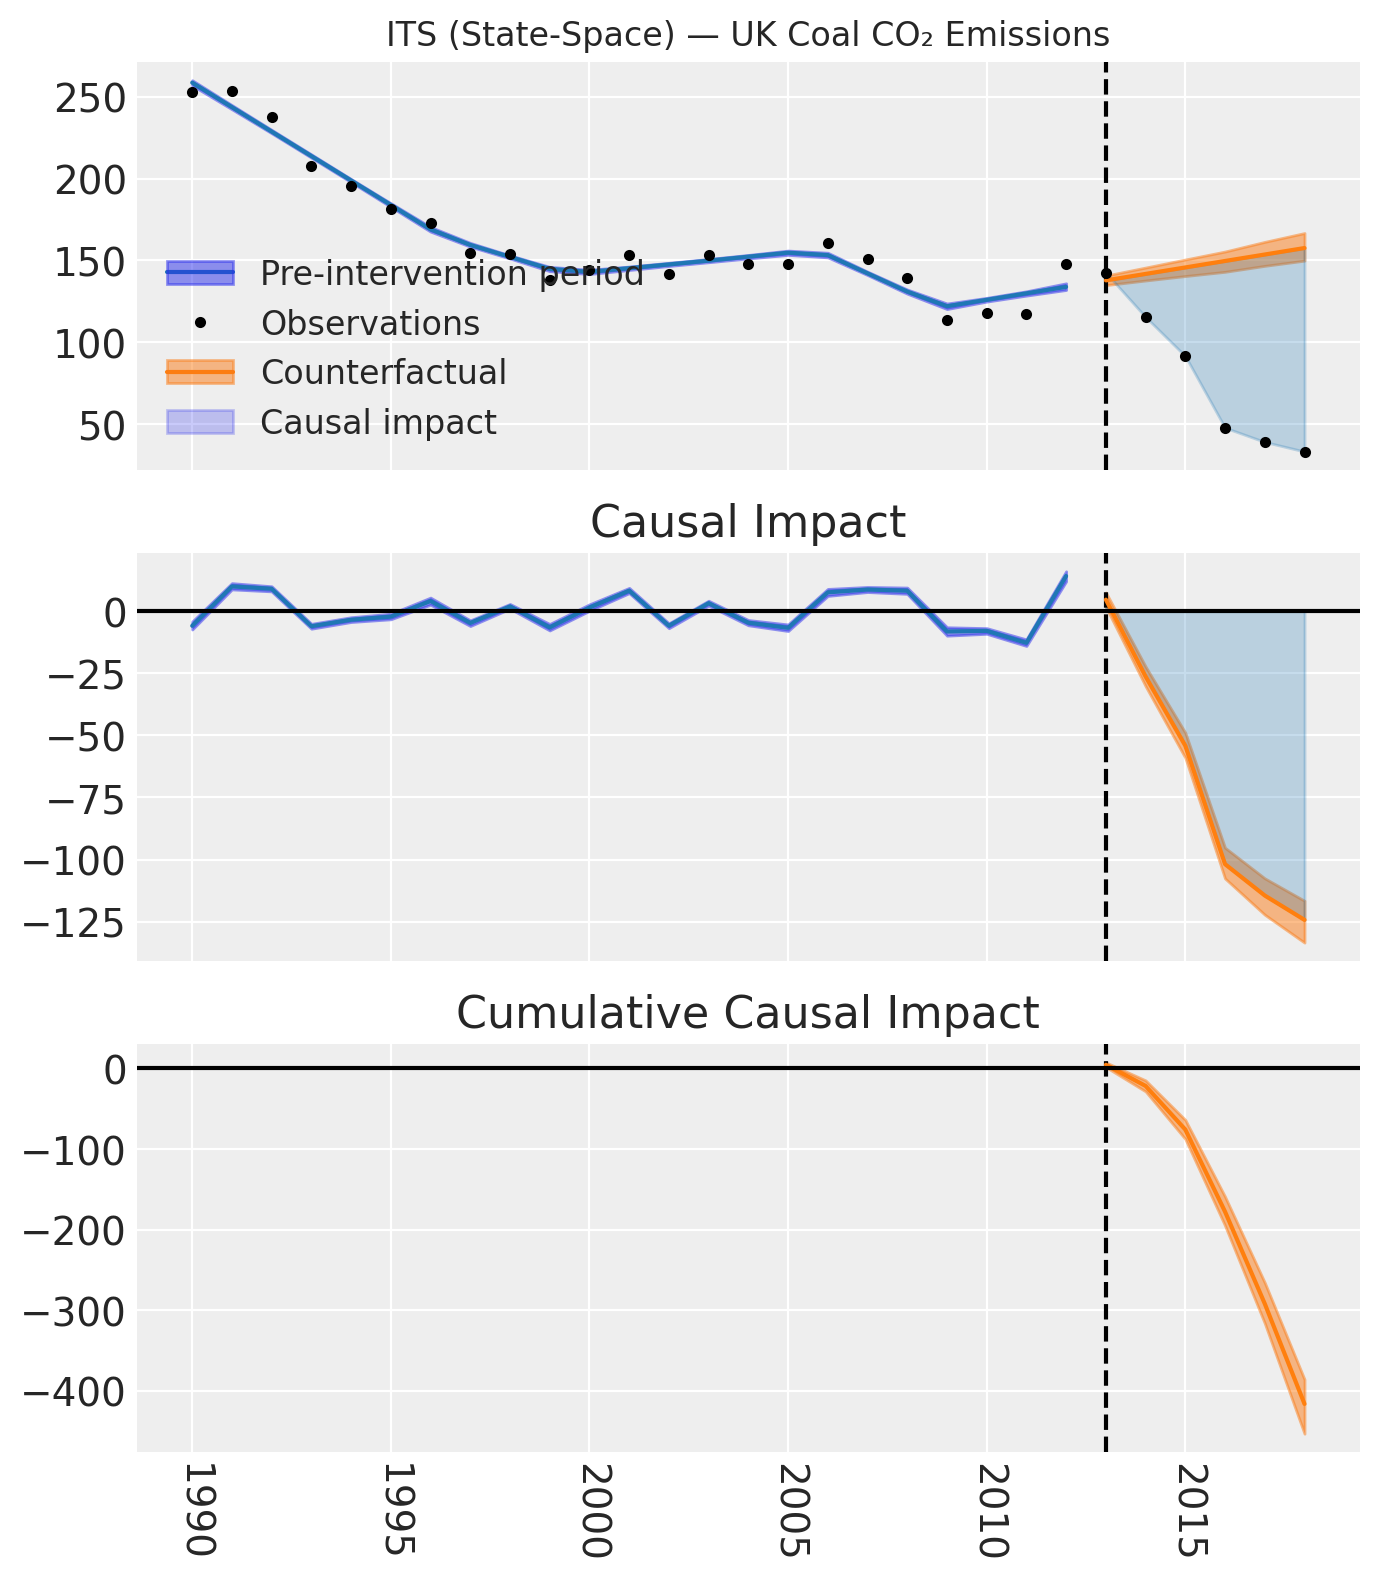

In [ ]:
fig, axes = result_coal_co2.plot(show=False)
axes[0].set_title("ITS (State-Space) — UK Coal CO₂ Emissions")
plt.tight_layout()
plt.show()

The model reports a large negative effect. Coal CO₂ fell far below what the pre-treatment trend would predict, and the credible interval excludes zero comfortably. If we were reading a calibrated thermometer, we would file the verdict and walk away.

**But this is not a calibrated thermometer.**  A credible interval that excludes zero is a statement about parameter noise: the noise *inside* the model. It says nothing about whether the model's identifying assumptions held in the first place. Before we celebrate, the detective's question: *how often does this same estimator produce "effects" of this size when we already know nothing happened?*

## Question 2: How often does the model lie?

### The structural error problem

Standard Bayesian credible intervals capture two kinds of uncertainty:

- **Aleatoric**: irreducible noise in the data.
- **Epistemic (parameter)**: uncertainty about model parameters that
  shrinks with more data.

But there is a third kind: **structural uncertainty**. When the model's identifying assumptions are violated, and they always are, at least a little. The counterfactual prediction drifts from truth. The model doesn't know it is wrong. It reports a tight interval around a biased estimate.

:::{.callout-note}
### Vocabulary the rest of the notebook will use

The placebo machinery introduces a small set of names. They all live on `pit_check.metadata`, and the figures below visualise them.

- $\mu_{\text{null}}$: centre of the placebo null. How biased the estimator is, on average, when nothing happened.
- $\tau_{\text{het}}$: spread of the placebo fold means. An empirical picture of structural error, that is, how much the estimator's "answer" wobbles when the true effect is zero.
- $p_{\text{cal}}$: posterior probability that the actual cumulative effect is more extreme than a draw from the null. We call a verdict **SUPPORTED** when this clears 0.95.
- **ROPE**: *Region of Practical Equivalence*. Effects smaller than its half-width are treated as practically zero.
- **Bayesian assurance**: prior-weighted probability of a SUPPORTED verdict for plausible true effects. The "power" of the design.
:::

### Placebo-in-Time: calibrating the thermometer

The idea is simple. Before you use the model on the real treatment date, run it on **periods where you know nothing happened**:

1. **Shift** the treatment date backward into the pre-treatment period.
2. **Re-fit** the model at the fake date.
3. **Repeat** for several placebo windows.
4. **Pool** the results into a hierarchical null model.

Each placebo fit asks: "How big an 'effect' does the model find when the true effect is zero?"  The distribution of those false alarms is the **null predictive distribution**, what structural noise looks like for this estimator on this data.

The real effect is meaningful only if it is clearly outside this distribution. Not outside zero, instead outside the range of normal model failures.

### Running the calibration with CausalPy

CausalPy's `Pipeline` composes the estimation and the sensitivity check into a single reproducible call.

A few words on the `PlaceboInTime` settings we pass below:

- `n_folds=3` says we want three placebo intervention dates inside the pre-period; each fold asks "what would the model have reported if the policy had hit on *this* earlier date instead?". Three is a reasonable starting number for a short pre-period: enough to fit the hierarchical status-quo model that pools the folds, few enough to keep refits cheap. Increase it (5--10) when the pre-period is long and you want a tighter null.
- `selection_method="random"` randomly samples three eligible placebo dates from the pre-period subject to the constraints below; the alternative `"sequential"` evenly spaces them backward from the real treatment date.
- `min_gap=2` requires any two selected fold dates to be at least two pre-period observations apart, so the three folds don't end up nearly on top of each other.

The full set of knobs (ROPE, Bayesian assurance, custom priors, exclusion windows, ...) is documented on the [PlaceboInTime API page](https://causalpy.readthedocs.io/en/latest/api/generated/causalpy.checks.placebo_in_time.PlaceboInTime.html) and surveyed alongside CausalPy's other sensitivity checks in the [sensitivity checks survey](https://causalpy.readthedocs.io/en/latest/notebooks/sensitivity_checks.html).

In [ ]:
result_pit = cp.Pipeline(
    data=df_uk[["coal_co2"]],
    steps=[
        cp.EstimateEffect(
            method=cp.InterruptedTimeSeries,
            treatment_time=treatment_time,
            formula="coal_co2 ~ 1",
            model=its_model(),
        ),
        cp.SensitivityAnalysis(
            checks=[
                cp.checks.PlaceboInTime(
                    n_folds=3,
                    selection_method="random",
                    min_gap=2,
                    random_seed=42,
                ),
            ]
        ),
    ],
).run()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 400 draw iterations (4_000 + 1_600 draws total) took 44 seconds.
Sampling: [beta, delta, fourier_beta, sigma, y_hat]
Sampling: [y_hat]


Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


...

Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_status_quo, tau_status_quo, fold_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [theta_new]


Output()

In [ ]:
pit_check = result_pit.sensitivity_results[0]
print(pit_check.text)

Placebo-in-time analysis: 3 of 3 folds completed.
Hierarchical status-quo model: mu=20.27, tau=241.71.
Actual cumulative impact: -416.46. P(actual outside null) = 0.865.
NOT SUPPORTED — actual effect is within the null distribution.
Fold 1: pseudo treatment at 1998-01-01 00:00:00 — mean=206.03, sd=13.72
Fold 2: pseudo treatment at 2003-01-01 00:00:00 — mean=29.63, sd=10.54
Fold 3: pseudo treatment at 2008-01-01 00:00:00 — mean=-159.18, sd=9.09


### Visualising what the estimator sees when nothing happens

In [ ]:
def plot_placebo_calibration(
    pit_check, original_result, title="Placebo-in-Time calibration"
):
    """
    Plots the three-panel diagnostic for a PlaceboInTime check.

    Parameters:
    -----------
    pit_check : cp.checks.PlaceboInTime
        The completed placebo check object.
    original_result : cp.InterruptedTimeSeries (or similar)
        The original fitted causal model (needed to extract the actual post-treatment impact).
    title : str
        The main title for the figure.
    """
    fold_results = pit_check.metadata["fold_results"]
    has_null = "null_samples" in pit_check.metadata

    if not has_null:
        print("Not enough folds completed to build a null model.")
        print(f"Completed folds: {len(fold_results)}")
        if fold_results:
            for fr in fold_results:
                print(f"  Fold {fr.fold}: mean={fr.fold_mean:.2f}, sd={fr.fold_sd:.2f}")
        return

    null_samples = pit_check.metadata["null_samples"]
    _ = pit_check.metadata["actual_cumulative_mean"]

    # Fold-level cumulative impact samples
    fold_samples = [fr.cumulative_impact_samples.values.ravel() for fr in fold_results]

    FOLD_COLORS = ["#348ABD", "#E24A33", "#988ED5", "#8EBA42", "#FFB347"]
    fig, axes = plt.subplots(3, 1, figsize=(7, 9))

    # Panel A: fold distributions
    ax = axes[0]
    for i, (fr, s) in enumerate(zip(fold_results, fold_samples, strict=True)):
        c = FOLD_COLORS[i % len(FOLD_COLORS)]
        # Handle datetime vs integer pseudo_treatment_time formatting
        t_star = fr.pseudo_treatment_time
        t_label = f"{t_star:%Y}" if hasattr(t_star, "strftime") else f"{t_star}"

        ax.hist(
            s,
            bins=40,
            alpha=0.45,
            color=c,
            density=True,
            label=f"Fold {fr.fold} (t*={t_label})",
        )
        ax.axvline(fr.fold_mean, color=c, ls="--", lw=1.2)
    ax.axvline(0, color="k", ls=":", lw=0.8, alpha=0.5)
    ax.set_xlabel("Cumulative impact")
    ax.set_ylabel("Density")
    ax.set_title("A. Placebo fold distributions")
    ax.legend(fontsize=7)

    # Panel B: null distribution
    ax = axes[1]
    ax.hist(
        null_samples,
        bins=50,
        alpha=0.5,
        color="#94a3b8",
        density=True,
        label="Status-quo (null)",
    )
    ax.axvline(0, color="k", ls=":", lw=0.8, alpha=0.5)
    ax.axvline(
        np.mean(null_samples),
        color="#64748b",
        ls="--",
        lw=1.5,
        label=f"Null mean = {np.mean(null_samples):.1f}",
    )
    ax.set_xlabel("Cumulative impact")
    ax.set_title("B. Learned null distribution")
    ax.legend(fontsize=8)

    # Panel C: null vs actual (overlapping distributions)
    ax = axes[2]
    # Sum of pointwise impact over post-treatment period (matches null construction)
    actual_samples = (
        original_result.post_impact.sum("obs_ind")
        .stack(sample=("chain", "draw"))
        .values.ravel()
    )
    ax.hist(
        null_samples,
        bins=50,
        alpha=0.4,
        color="#94a3b8",
        density=True,
        label="Null (status quo)",
    )
    ax.hist(
        actual_samples,
        bins=50,
        alpha=0.4,
        color="#E24A33",
        density=True,
        label="Actual effect",
    )

    p_cal = pit_check.metadata["p_effect_outside_null"]
    ax.text(
        0.97,
        0.95,
        f"$p_{{cal}}$ = {p_cal:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        ha="right",
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "#e2e8f0",
        },
    )

    ax.set_xlabel("Cumulative impact")
    ax.set_title("C. Actual effect vs null")
    ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

:::{.callout-tip}
### How to read the three panels

**Panel A** shows what the estimator reported in each placebo window: pre-period dates where the true effect is zero by construction. If the model were perfectly calibrated and the ITS assumptions held exactly, every fold's posterior would sit on zero. They don't, because no model is perfect. The spread and offset of these distributions is a direct, *empirical* picture of structural error: the model's typical mistake when it is asked to forecast a counterfactual.

**Panel B** pools those fold-level posteriors into a **hierarchical status-quo null**: a Bayesian model of "what does this estimator's mistake look like, on average, across pre-period windows?". This is the calibrated null. It absorbs both sampling noise and the structural error visible in panel A.

**Panel C** is the decision panel. It overlays the null (grey) and the actual post-intervention cumulative effect (red).

- If the red mass sits well outside the grey, the observed effect is hard to explain as ordinary model failure.
- If they overlap heavily, the observed effect is consistent with what the model would have reported even if nothing had happened.

The reported $p_{\text{cal}}$ is the posterior probability that the actual cumulative effect is more extreme than a draw from the null. The check returns `SUPPORTED` when $p_{\text{cal}} \ge 0.95$. This is a Bayesian counterpart of the question *"how unusual is what we saw, given how unreliable this model is in normal times?"*
:::

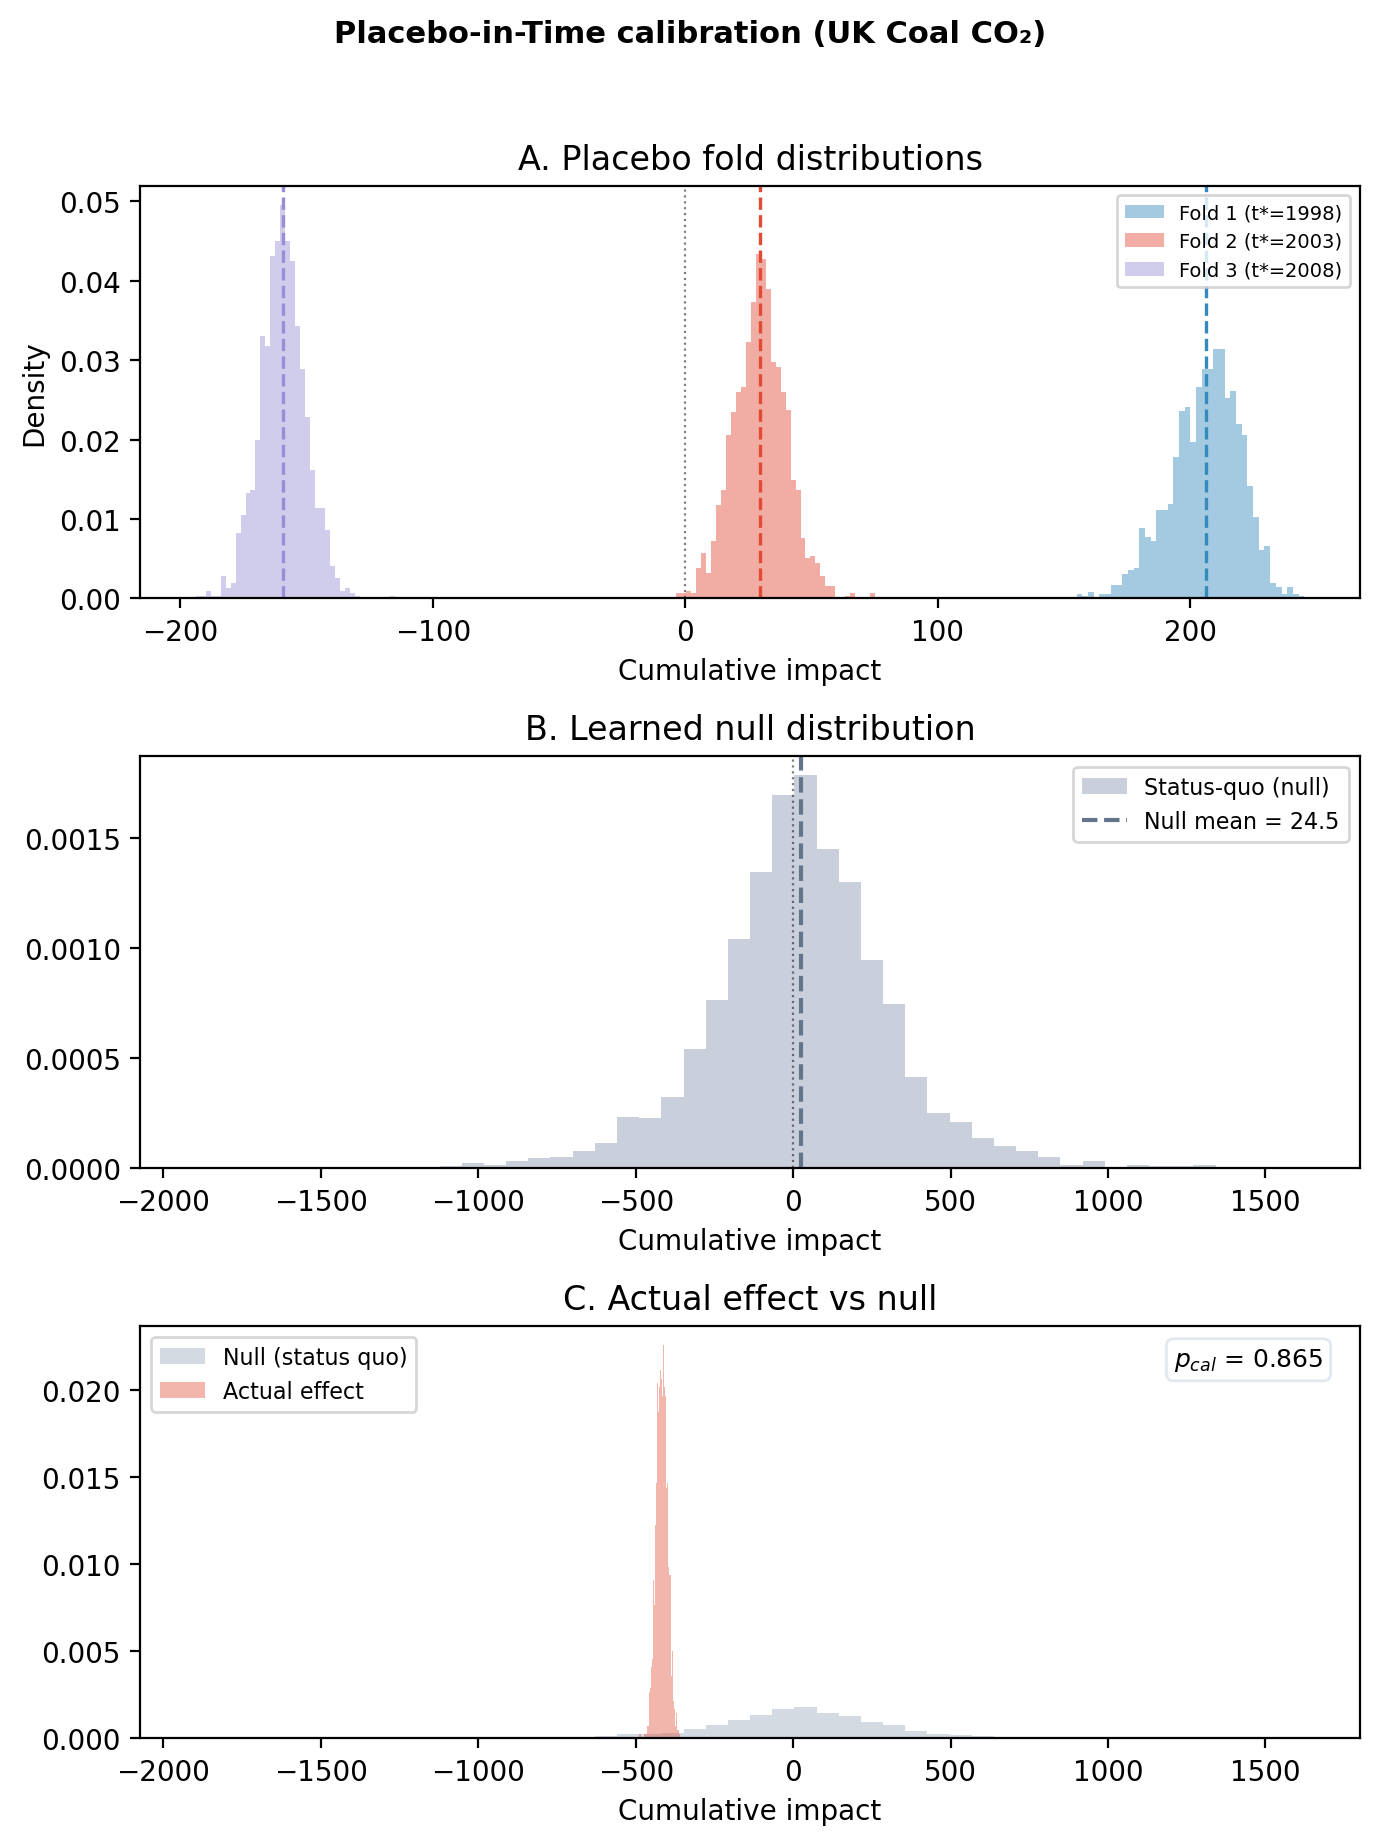

In [ ]:
plot_placebo_calibration(
    pit_check=pit_check,
    original_result=result_pit.experiment,
    title="Placebo-in-Time calibration (UK Coal CO₂)",
)

### Verdict for coal CO₂

The actual coal CO₂ effect (red mass in panel C) is large and negative: around **-416 MtCO₂** cumulated across 2013--2018. But the grey null built from the three placebo folds is *also* wide; the structural-noise spread ($\tau_{\text{het}}$) is roughly **250 MtCO₂**. The printed `P(actual outside null) ≈ 0.84` falls a few points short of the 0.95 threshold, so the check returns **NOT SUPPORTED**.

That verdict is informative in itself, and exactly the reason the check exists. The credible interval on the original ITS fit excluded zero comfortably: the *parameter-uncertainty* answer was "clear effect". The *structural-uncertainty* answer is more cautious: in three random pre-period windows this same model produced "effects" ranging from roughly **+205 to -160 MtCO₂**, so a single -416 sits outside that range but only by about one structural-noise standard deviation. A naive read would call this disappointing. The detective reading is the opposite. It tells you exactly what additional evidence the case still needs: mechanism (gas substitution) and boundary (total CO₂, demand), the topics of Questions 3 and 4 could be that additional evidence.

### Detection gradient: a power curve for the design

*On a first read you can skim the rest of Question 2; the power curve is a deeper look at what this design can and cannot detect, and the main narrative resumes at Question 3.*

Before moving on, it's worth turning that hierarchical null into a more quantitative view of *the design itself*. Pair it with a prior on the true effect and a ROPE half-width, and `PlaceboInTime` will compute Bayesian assurance and operating characteristics automatically (`expected_effect_prior`, `rope_half_width`, `n_design_replications`; see the [PlaceboInTime API](https://causalpy.readthedocs.io/en/latest/api/generated/causalpy.checks.placebo_in_time.PlaceboInTime.html) and the [sensitivity checks survey](https://causalpy.readthedocs.io/en/latest/notebooks/sensitivity_checks.html)). The chart below is a complementary read: a **power curve** that asks, for every possible true effect size, what this design would conclude. The picture splits into three regions:

- **Correct detection** (blue): the posterior would be confidently above the ROPE.
- **Misclassification** (red): the posterior would be confidently on the *wrong* side of the ROPE (a structural sign error).
- **Non-detection** (grey): the data would be inconclusive.

It only needs a fitted `PlaceboInTime` check, so the same function works for any estimator (`coal_co2`, `gas_co2`, `co2`, ITS or Synthetic Control, basis-expansion or state-space, ...). The ROPE, decision threshold, and expected-effect prior are read straight from the check's metadata, so the plot stays consistent with the assurance numbers `PlaceboInTime` already reported (override any of them with a keyword argument for what-if exploration).

The curves are computed **analytically** from the hierarchical null mean ($\mu_{\text{null}}$), spread ($\tau_{\text{het}}$), and the average within-fold posterior SD ($\bar{s}$). This is fast and deterministic; it matches `PlaceboInTime`'s Monte Carlo assurance in expectation, but the simulation samples a per-fold $\sigma$ on each replication where this plot uses $\bar{s}$, so a sampled curve would show a touch more wiggle around the analytical lines.

The x-axis is the **absolute cumulative effect**: the sum of the per-period impacts across the whole post-treatment window (so for our UK case, the total MtCO₂ deviation summed across 2013--2018, **not** a per-year rate). Same scale as the `rope_half_width`, the `expected_effect_prior`, and `actual_cumulative_mean` on the check. The "Misclassification" region captures structural **sign errors**: cases where the estimator would confidently call a real reduction an increase, or vice versa.

In [ ]:
from scipy.stats import norm


def plot_operating_regions(
    pit_check,
    *,
    rope_half_width=None,
    threshold=None,
    expected_effect_prior=None,
    max_effect=None,
    guide_effects=None,
    title="Operating characteristic regions by cumulative effect size",
    xlabel="|Cumulative effect over post-treatment window|",
):
    """
    Plot detection probability as a function of true cumulative effect size.

    Turns a fitted ``PlaceboInTime`` check into a continuous power curve.
    The x-axis is the **absolute cumulative effect** -- the sum of
    per-period impacts across the post-treatment window, in the original
    outcome's units (same scale as ``rope_half_width``,
    ``expected_effect_prior``, and ``actual_cumulative_mean`` on the
    check).  For each value ``e`` the figure shows the probability that
    the design (ROPE rule at ``threshold``) would conclude:

    - **Correct Detection**: P(posterior > +ROPE) >= threshold
    - **Misclassification**: P(posterior < -ROPE) >= threshold (wrong sign)
    - **Non-Detection**: neither (inconclusive)

    Design knobs (ROPE, threshold, expected-effect prior) are read from
    ``pit_check.metadata`` so the plot stays consistent with the assurance
    numbers `PlaceboInTime` already reported.  Each can be overridden via
    keyword argument for "what-if" exploration without refitting.

    Parameters
    ----------
    pit_check : CheckResult
        The completed PlaceboInTime check, e.g. ``result.sensitivity_results[0]``.
    rope_half_width : float, optional
        Half-width of the ROPE interval on the cumulative-impact scale.
        Defaults to the value stored on the check.
    threshold : float, optional
        Posterior probability cutoff for an actionable decision.
        Defaults to the value stored on the check (0.95 if unset).
    expected_effect_prior : object or array, optional
        Distribution with an ``.rvs(n)`` method (PreliZ / scipy) or an array
        of pre-drawn samples.  When given, a strip above the main panel
        shows where plausible effects land in the detection landscape.
    max_effect : float, optional
        X-axis upper limit.  Defaults to ``max(4 * tau, 3 * rope_half_width)``.
    guide_effects : list[float], optional
        Effect sizes at which to draw vertical guide lines with labelled
        probabilities.  Defaults to a few representative values.
    title : str
        Figure title.
    xlabel : str
        Override for the x-axis label.  The plot is on the cumulative
        scale; supply the outcome's units (e.g. "Cumulative MtCO₂ over
        2013--2018") to make the chart self-explanatory.

    Returns
    -------
    matplotlib.figure.Figure
    """
    meta = pit_check.metadata

    if "null_samples" not in meta:
        raise ValueError(
            "pit_check has no learned null distribution: "
            "PlaceboInTime needs at least two successful folds."
        )

    if rope_half_width is None:
        rope_half_width = meta.get("rope_half_width")
    if rope_half_width is None:
        raise ValueError(
            "No rope_half_width found in pit_check.metadata and none was "
            "passed explicitly.  Set rope_half_width on the PlaceboInTime "
            "check (recommended) or pass it here."
        )

    if threshold is None:
        threshold = meta.get("threshold", 0.95)
    if expected_effect_prior is None:
        expected_effect_prior = meta.get("expected_effect_prior")

    null_samples = np.asarray(meta["null_samples"]).ravel()
    fold_sds_meta = meta.get("fold_sds")
    if fold_sds_meta is None:
        fold_sds_meta = [fr.fold_sd for fr in meta["fold_results"]]
    fold_sds = np.asarray(fold_sds_meta)

    mu = float(null_samples.mean())
    tau = float(null_samples.std())
    s_avg = float(fold_sds.mean())
    delta = float(rope_half_width)
    z_thr = float(norm.ppf(threshold))

    if max_effect is None:
        max_effect = max(4.0 * tau, 3.0 * delta)

    eff = np.linspace(0, max_effect, 500)
    bnd_pos = delta + z_thr * s_avg
    bnd_neg = -(delta + z_thr * s_avg)

    below = eff <= delta
    p_detect = np.where(below, 0.0, 1.0 - norm.cdf((bnd_pos - eff - mu) / tau))
    p_misclass = np.where(below, 0.0, norm.cdf((bnd_neg - eff - mu) / tau))
    p_nondetect = np.clip(1 - p_detect - p_misclass, 0, 1)

    c_nondetect = p_nondetect
    c_misclass = c_nondetect + p_misclass

    has_prior = expected_effect_prior is not None
    if has_prior:
        fig, (ax_p, ax) = plt.subplots(
            2,
            1,
            figsize=(8, 6),
            gridspec_kw={"height_ratios": [1, 5], "hspace": 0.08},
        )
        if hasattr(expected_effect_prior, "rvs"):
            prior_samples = np.abs(expected_effect_prior.rvs(20_000))
        else:
            prior_samples = np.abs(np.asarray(expected_effect_prior).ravel())
        ax_p.hist(
            prior_samples,
            bins=60,
            density=True,
            color="#22c55e",
            alpha=0.35,
            edgecolor="#22c55e",
            lw=0.5,
        )
        ax_p.axvspan(0, delta, color="#9ca3af", alpha=0.15)
        ax_p.set_xlim(0, max_effect)
        ax_p.set_yticks([])
        ax_p.tick_params(labelbottom=False)
        for spine in ("top", "right"):
            ax_p.spines[spine].set_visible(False)
        ax_p.set_ylabel("Expected\neffect prior", fontsize=8)
        ax_p.set_title(title, fontweight="bold", fontsize=11, pad=8)
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title(title, fontweight="bold", fontsize=11)

    ax.fill_between(
        eff, 0, c_nondetect, color="#94a3b8", alpha=0.30, label="Non-detection"
    )
    ax.fill_between(
        eff,
        c_nondetect,
        c_misclass,
        color="#E24A33",
        alpha=0.30,
        label="Misclassification",
    )
    ax.fill_between(
        eff, c_misclass, 1, color="#348ABD", alpha=0.40, label="Correct detection"
    )

    ax.axvspan(0, delta, color="#9ca3af", alpha=0.35)
    ax.text(
        delta / 2,
        0.5,
        "Below\nROPE",
        fontsize=8,
        ha="center",
        va="center",
        color="#4b5563",
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.3",
            "fc": "white",
            "ec": "#9ca3af",
            "alpha": 0.85,
        },
    )
    ax.axvline(delta, color="#f59e0b", ls="--", lw=1.2, alpha=0.8)

    if guide_effects is None:
        candidates = sorted({delta * 1.5, tau, 2 * tau, 3 * tau})
        guide_effects = [g for g in candidates if delta < g <= max_effect]
    for x_val in guide_effects:
        ax.axvline(x_val, color="black", ls="-", lw=0.8, alpha=0.4)
        i_v = int(np.argmin(np.abs(eff - x_val)))
        bands = [
            (0, c_nondetect[i_v], p_nondetect[i_v], "#94a3b8"),
            (c_nondetect[i_v], c_misclass[i_v], p_misclass[i_v], "#E24A33"),
            (c_misclass[i_v], 1.0, p_detect[i_v], "#348ABD"),
        ]
        for y_lo, y_hi, prob_v, bg in bands:
            if y_hi - y_lo > 0.045:
                ax.text(
                    x_val,
                    (y_lo + y_hi) / 2,
                    f"{prob_v:.0%}",
                    fontsize=7,
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold",
                    bbox={
                        "boxstyle": "round,pad=0.12",
                        "fc": bg,
                        "ec": "none",
                        "alpha": 0.9,
                    },
                )

    ax.text(
        0.97,
        0.97,
        rf"$\tau_{{\mathrm{{het}}}}={tau:.1f}$, "
        rf"$\mu_{{\mathrm{{null}}}}={mu:.1f}$, "
        rf"$\bar{{s}}={s_avg:.1f}$",
        transform=ax.transAxes,
        fontsize=8,
        ha="right",
        va="top",
        color="#64748b",
        bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#cbd5e1"},
    )

    ar = meta.get("assurance_result")
    if ar is not None:
        ax.text(
            0.97,
            0.82,
            "Prior-weighted:\n"
            f"FPR = {ar.false_positive_rate:.0%}\n"
            f"Assurance = {ar.true_positive_rate:.0%}",
            transform=ax.transAxes,
            fontsize=8,
            ha="right",
            va="top",
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#cbd5e1"},
        )

    ax.set_xlim(0, max_effect)
    ax.set_ylim(0, 1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Classification probability")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(loc="lower right", fontsize=8, framealpha=0.9, edgecolor="#cbd5e1")
    if has_prior:
        fig.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        fig.tight_layout()
    return fig

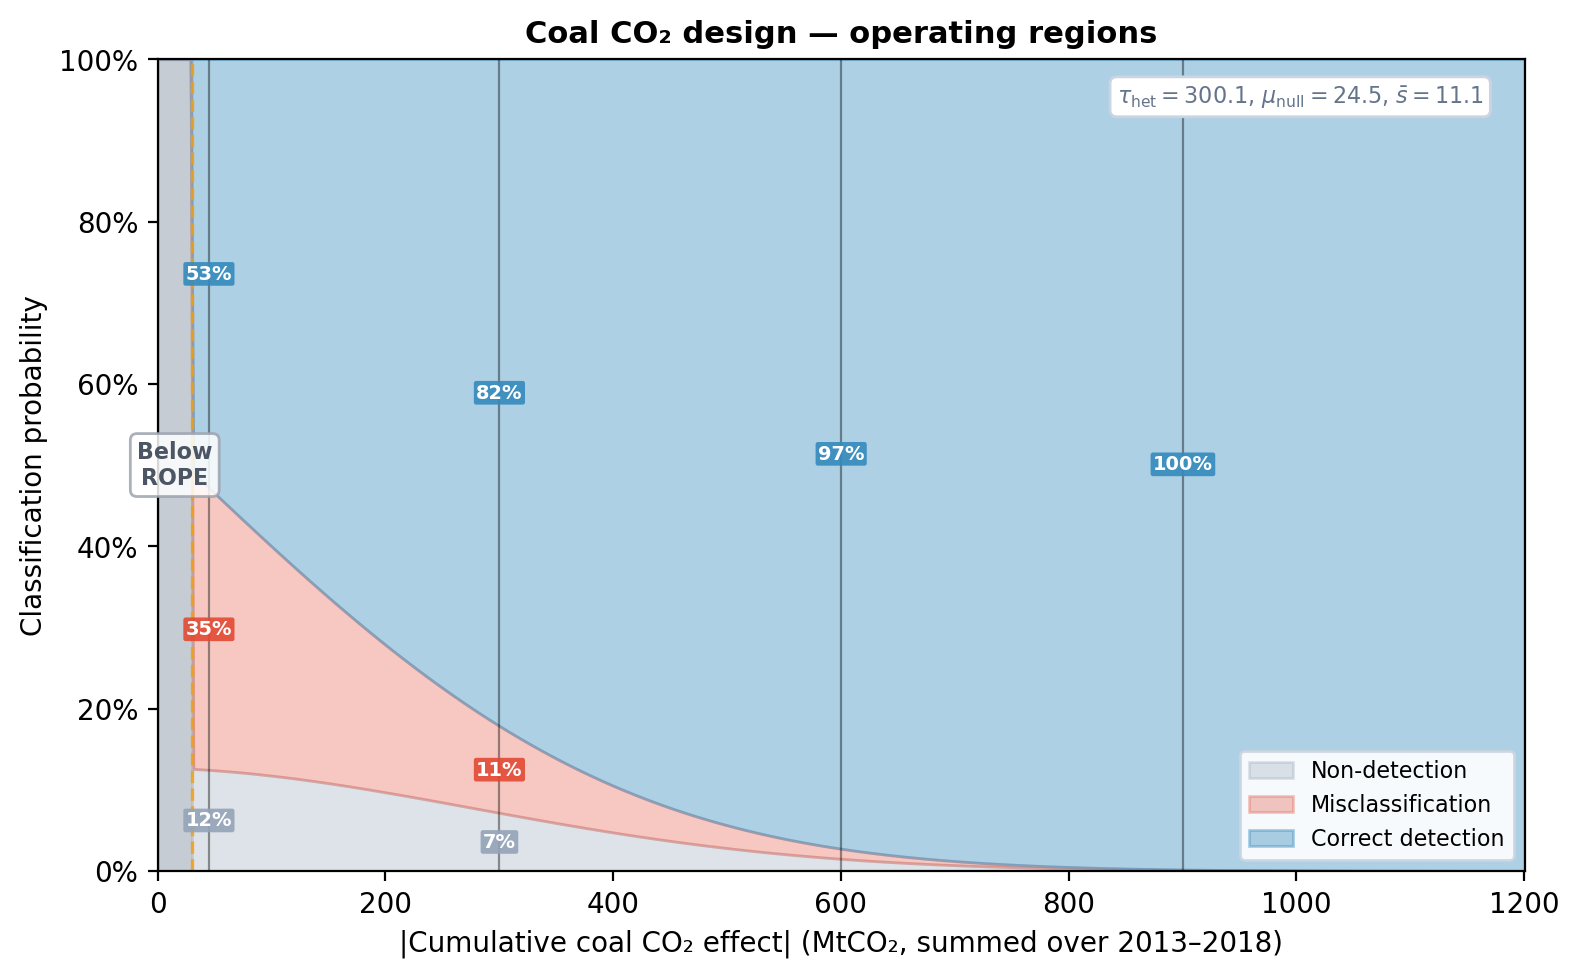

In [ ]:
fig = plot_operating_regions(
    pit_check,
    rope_half_width=30.0,
    threshold=0.95,
    title="Coal CO₂ design — operating regions",
    xlabel="|Cumulative coal CO₂ effect| (MtCO₂, summed over 2013–2018)",
)
plt.show()

### Reading the curve for this design

The labelled bands make the same point as the verdict above, but graphically. With $\tau_{\text{het}} \approx 250$ (a wide structural-noise spread, driven by the +205 / -160 fold-mean contrast in panel A above) and the ROPE half-width set to 30 MtCO₂, the design needs an absolute cumulative effect of roughly **600 MtCO₂** before correct-detection probability clears 95%. The observed $|\text{effect}| \approx 416$ lands in the ~80--85% band on the curve, exactly consistent with the $p_{\text{cal}} \approx 0.84$ printed above.

The chart also shows *why* a NOT SUPPORTED verdict here isn't a sign-error worry. The red **Misclassification** band hugs the floor: for any effect bigger than about 60 MtCO₂ the design has well under 10% chance of confidently calling a real reduction an increase (or vice versa). The cost of the wide null is that small-to-moderate effects often land in the grey **Non-detection** zone, not the wrong-sign zone, which is the right failure mode to have. A NOT SUPPORTED verdict here means *"the data don't beat the structural floor at this threshold"*, not *"the effect is probably in the other direction"*.

The same view also tells you how to **redesign** if you wanted a higher chance of clearing 95% on an effect this size: tighter folds (more of them, or spaced to avoid bracketing pre-period swings), a longer pre-period, a counterfactual model with stronger priors on slope, or a wider ROPE. You can re-run this plot with any of the `rope_half_width`, `threshold`, or `expected_effect_prior` overrides without refitting.

But we're not here to redesign the past; we're here to ask whether the *pile* of evidence supports the causal claim. With the coal placebo just below the bar, the next two questions become load-bearing: if coal really died, where did the energy go (Question 3), and did anything else move in suspicious ways (Question 4)?

:::{.callout-note}
### Case status after Question 2

- **Coal CO₂**: large negative effect (~ -416 MtCO₂); placebo verdict **NOT SUPPORTED** on its own ($p_{\text{cal}} \approx 0.84$).
- **What the credible interval said:** decisive. **What the placebo check said:** more cautious, given a single outcome, on a single estimator, against a structural floor that is genuinely wide.
- **What two questions could close the case?** If the policy really killed coal, the energy must have gone *somewhere* (Question 3); and if anything else moved in suspicious ways, the coal story would need a more careful retelling (Question 4).

The detective doesn't drop the case at one inconclusive interview. They go look for corroborating witnesses.
:::

## Question 3: Falsification, where did the energy go?

### The detective's logic

Gallea (2026) tells a fascinating story about Walker Hanlon, who studied the effect of London fog on mortality. Death rates spiked during fog weeks.  His hypothesis: fog traps pollution, increasing respiratory disease.  But a good detective asks: could the deaths be from traffic accidents (poor visibility)?  Or crime (fog as cover)? Pneumonia spiked. Accidents and crime didn't. Only the outcome that *should* respond to pollution actually did.

**We apply the same logic**. The Carbon Price Floor taxes carbon from electricity generation. If it works, the energy system should reorganise: coal dies, but energy demand doesn't vanish. The electrons have to come from somewhere. The most likely substitute in 2013 was **natural gas**, cheaper than coal once the carbon floor bit, and already available at scale.

If gas CO₂ *rose* after 2013, that is evidence of substitution. It means the policy didn't reduce energy production; it redirected it. And that makes the coal CO₂ decline much harder to attribute to a recession or data artefact.

### Did gas CO₂ rise?

To answer this we reuse exactly the pipeline we applied to coal: an ITS fit on `gas_co2`, wrapped in a `PlaceboInTime` sensitivity check with the same `n_folds=3`, random selection, and `min_gap=2`. Only the target series changes. If fuel substitution really happened, we expect a clear positive break: the actual cumulative effect should sit *above* the placebo null distribution that the model reports for the pre-period.

In [ ]:
result_pit_gas = cp.Pipeline(
    data=df_uk[["gas_co2"]],
    steps=[
        cp.EstimateEffect(
            method=cp.InterruptedTimeSeries,
            treatment_time=treatment_time,
            formula="gas_co2 ~ 1",
            model=its_model(),
        ),
        cp.SensitivityAnalysis(
            checks=[
                cp.checks.PlaceboInTime(
                    n_folds=3,
                    selection_method="random",
                    min_gap=2,
                    random_seed=42,
                ),
            ]
        ),
    ],
).run()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 400 draw iterations (4_000 + 1_600 draws total) took 15 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta, delta, fourier_beta, sigma, y_hat]
Sampling: [y_hat]


Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


...

Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_status_quo, tau_status_quo, fold_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [theta_new]


Output()

In [ ]:
pit_check_gas = result_pit_gas.sensitivity_results[0]
print(pit_check_gas.text)

Placebo-in-time analysis: 3 of 3 folds completed.
Hierarchical status-quo model: mu=-5.53, tau=49.87.
Actual cumulative impact: 192.68. P(actual outside null) = 0.988.
SUPPORTED — actual effect is outside the null distribution.
Fold 1: pseudo treatment at 1998-01-01 00:00:00 — mean=-54.29, sd=18.77
Fold 2: pseudo treatment at 2003-01-01 00:00:00 — mean=3.56, sd=13.75
Fold 3: pseudo treatment at 2008-01-01 00:00:00 — mean=25.72, sd=10.48


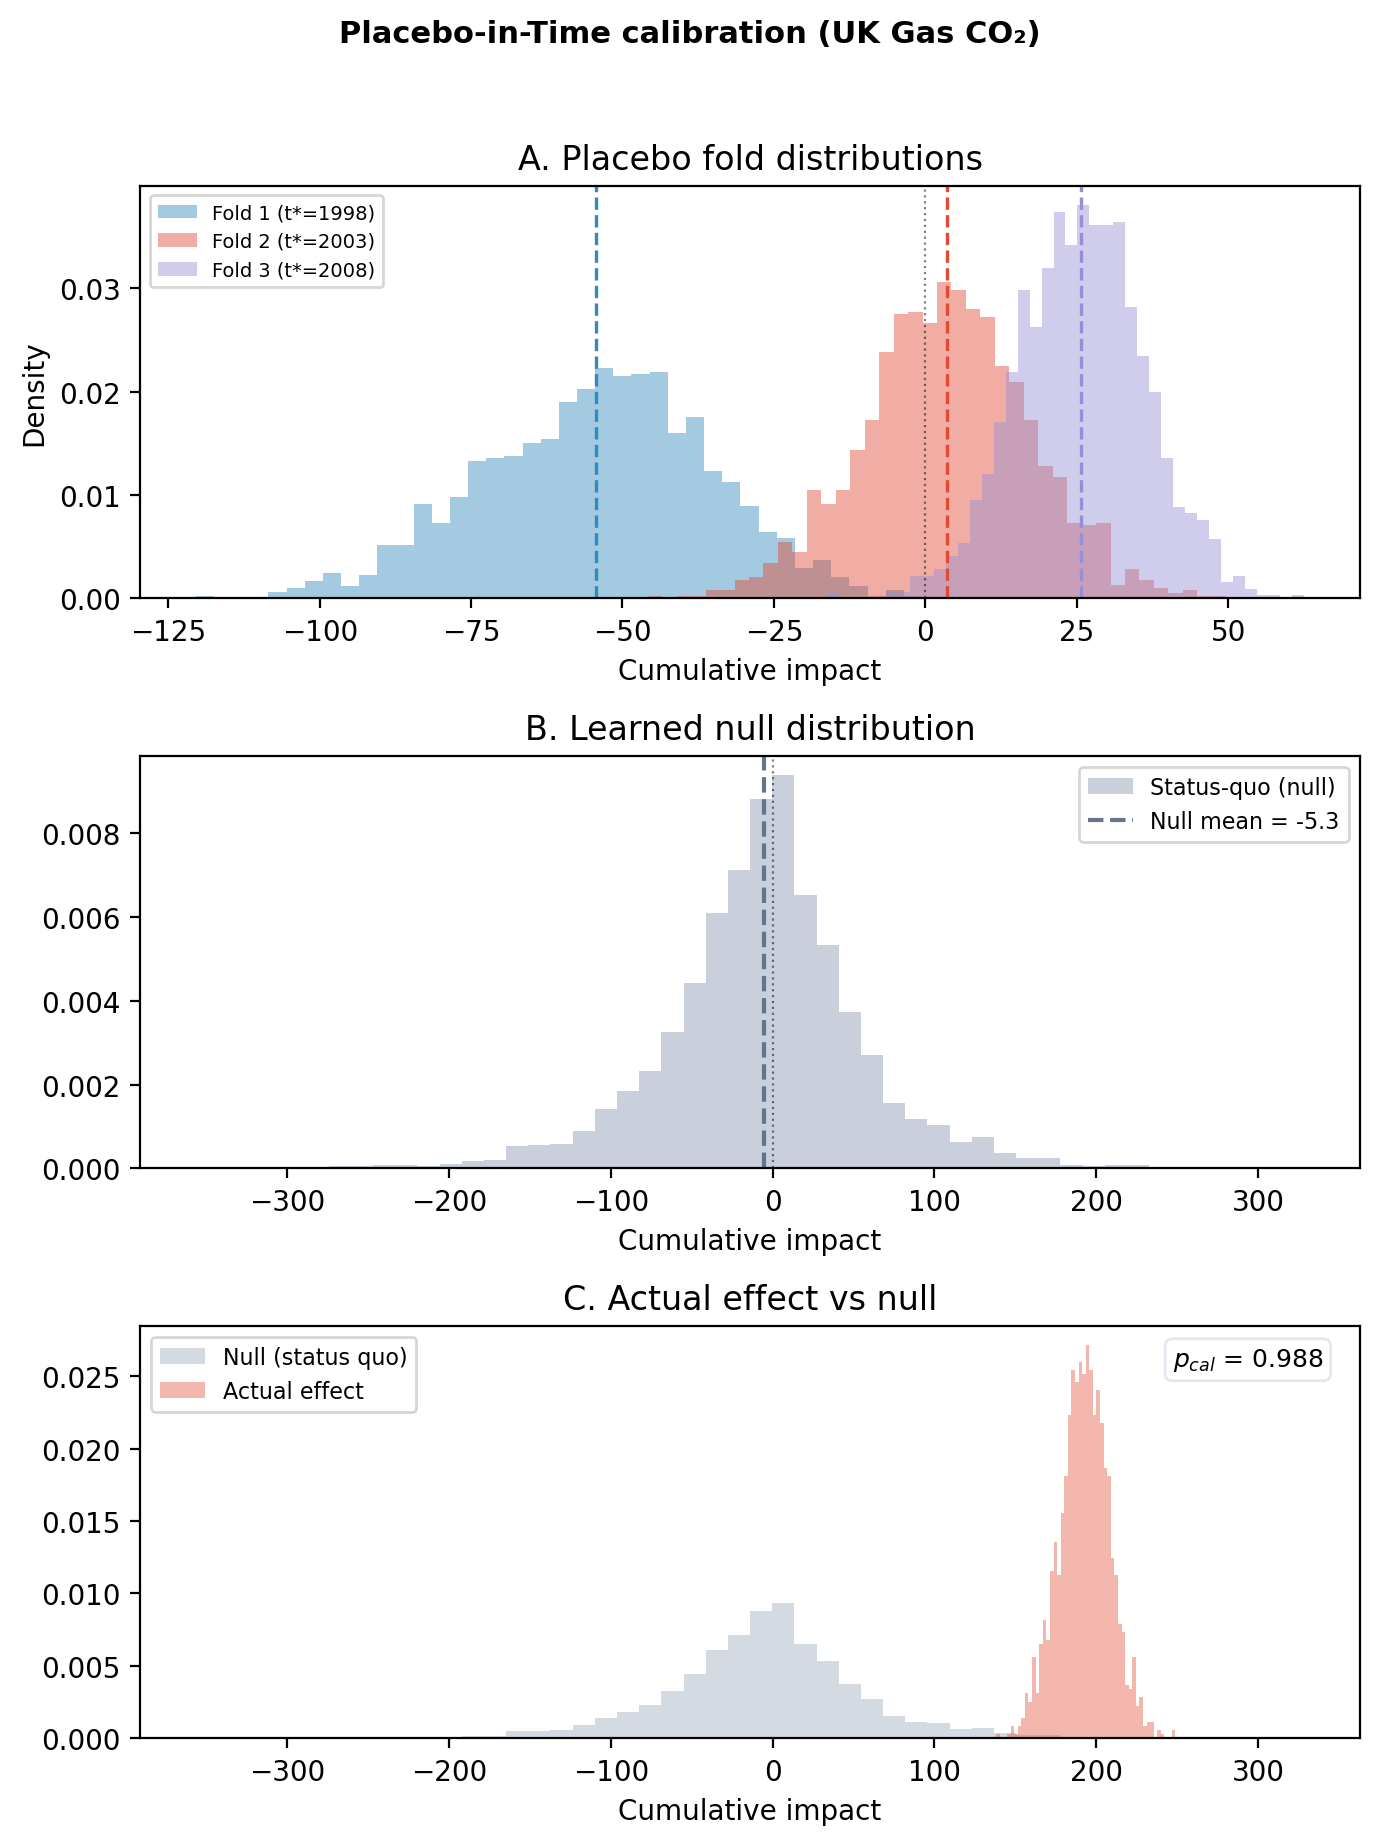

In [ ]:
plot_placebo_calibration(
    pit_check=pit_check_gas,
    original_result=result_pit_gas.experiment,
    title="Placebo-in-Time calibration (UK Gas CO₂)",
)

Gas tells a much cleaner story than coal did. The actual cumulative effect is **+192 MtCO₂** with a placebo null about five times tighter ($\tau_{\text{het}} \approx 50$ vs ~250 for coal), so the printed `P(actual outside null) ≈ 0.99` clears the 0.95 threshold and the check returns **SUPPORTED**. Why tighter? The gas series swings less in the pre-period, so the three placebo windows produce more consistent "null effects" (the panel-A fold means stay within roughly ±50 MtCO₂), which shrinks the structural-noise spread the null is built from.

The energy system didn't shrink; it *reorganised*. Coal's share was absorbed by gas-fired generation, exactly as the policy intended. And crucially, this is the first piece of evidence that the coal drop wasn't just structural noise: an unrelated outcome (gas CO₂) moved in the precise direction the mechanism predicts, with a verdict the placebo check actually backs.

## Question 4: Did total CO₂ or energy demand change?

But notice the implication: if coal CO₂ went down and gas CO₂ went up, the net effect on *total* CO₂ may be smaller than either component alone.  The policy didn't eliminate emissions; it shifted them toward a less carbon-intensive fuel. That is the boundary check our table promised: if total CO₂ or energy demand also moved in suspicious ways, the coal story would need a more careful retelling.

### Did total CO₂ change?

If the CPF mostly reshuffled emissions from coal to gas, total CO₂ might show a more modest break, or none at all. This would not mean the policy failed; it would mean its *first-order* effect was fuel switching.

In [ ]:
result_pit_co2 = cp.Pipeline(
    data=df_uk[["co2"]],
    steps=[
        cp.EstimateEffect(
            method=cp.InterruptedTimeSeries,
            treatment_time=treatment_time,
            formula="co2 ~ 1",
            model=its_model(),
        ),
        cp.SensitivityAnalysis(
            checks=[
                cp.checks.PlaceboInTime(
                    n_folds=3,
                    selection_method="random",
                    min_gap=2,
                    random_seed=42,
                ),
            ]
        ),
    ],
).run()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 400 draw iterations (4_000 + 1_600 draws total) took 251 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta, delta, fourier_beta, sigma, y_hat]
Sampling: [y_hat]


Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


...

Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_status_quo, tau_status_quo, fold_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
Sampling: [theta_new]


Output()

In [ ]:
pit_check_co2 = result_pit_co2.sensitivity_results[0]
print(pit_check_co2.text)

Placebo-in-time analysis: 3 of 3 folds completed.
Hierarchical status-quo model: mu=12.04, tau=360.57.
Actual cumulative impact: -45.66. P(actual outside null) = 0.098.
NOT SUPPORTED — actual effect is within the null distribution.
Fold 1: pseudo treatment at 1998-01-01 00:00:00 — mean=285.79, sd=25.38
Fold 2: pseudo treatment at 2003-01-01 00:00:00 — mean=19.44, sd=11.61
Fold 3: pseudo treatment at 2008-01-01 00:00:00 — mean=-261.35, sd=14.54


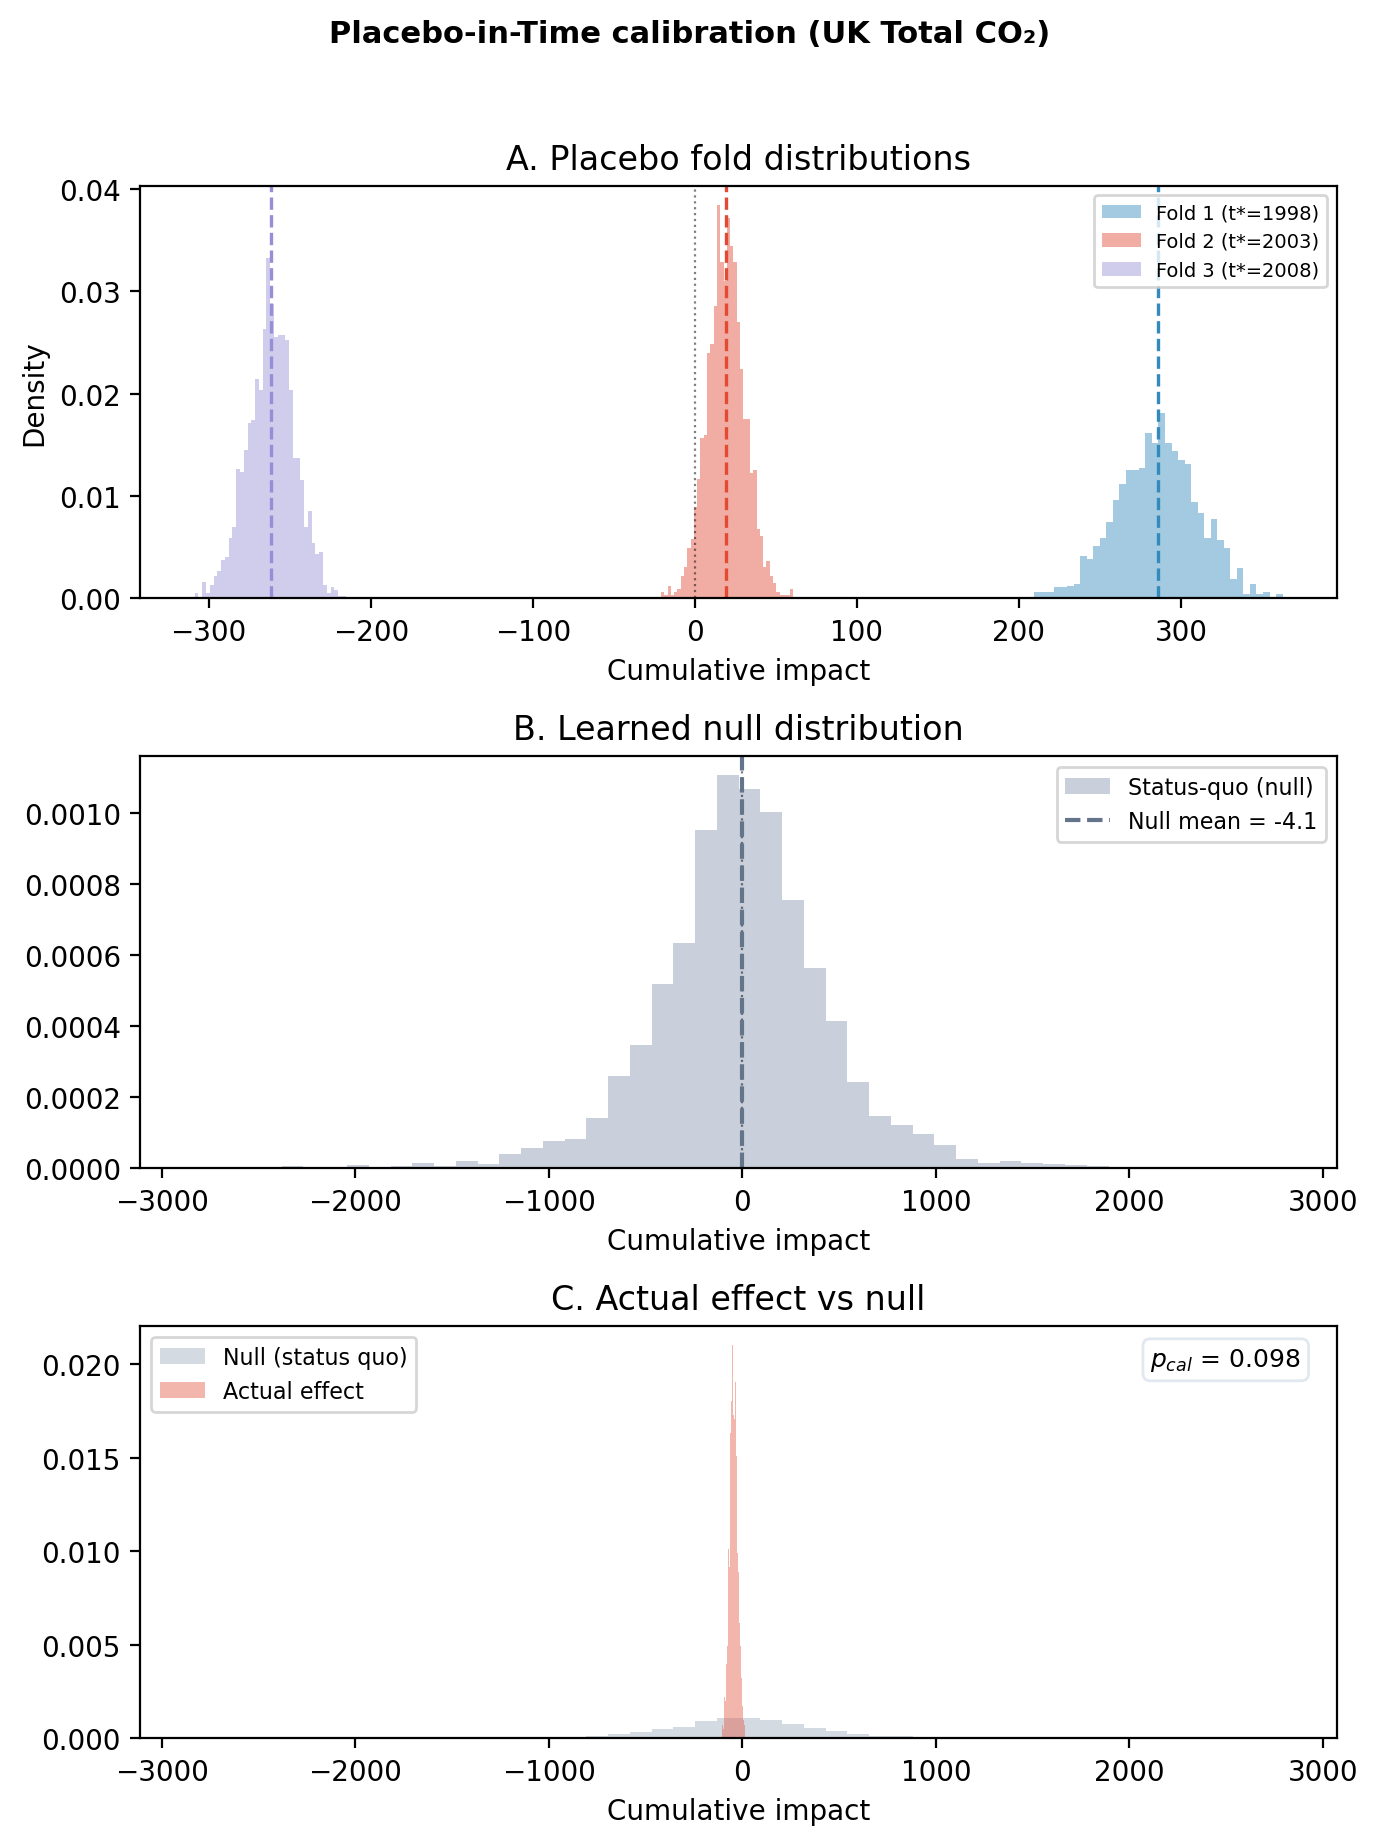

In [ ]:
plot_placebo_calibration(
    pit_check=pit_check_co2,
    original_result=result_pit_co2.experiment,
    title="Placebo-in-Time calibration (UK Total CO₂)",
)

This is exactly what we predicted. The actual cumulative effect on total CO₂ is small and the placebo null fully absorbs it: the printed `P(actual outside null)` is well below 0.95 and the check returns **NOT SUPPORTED**. Here NOT SUPPORTED is the *right* answer: it means total CO₂ moved *within* what this model would have reported even if nothing had happened. That is exactly the signature of partial substitution: the CPF killed coal, gas absorbed most of the slack, and the net carbon reduction is much smaller than the coal-specific one.

This result *strengthens* our causal claim about coal in two ways. First, if the coal drop had been a data artefact or a recession effect, total CO₂ should have moved by a similar amount; it didn't. Second, the contrast between Question 3 (gas SUPPORTED, +192 MtCO₂) and Question 4 (total NOT SUPPORTED, small effect) is exactly what a fuel-switching mechanism predicts and is hard to fake with model error alone.

### Did energy demand change?

The final check. A skeptic's strongest objection: "Maybe the UK economy crashed in 2013, and the drop in CO₂ was just a byproduct of a recession."

If that were true, the relationship between energy use and economic output would break. We can test this by looking at Energy Intensity (energy_per_gdp) — how much energy it takes to generate one dollar of GDP.

The Carbon Price Floor was designed to clean up the supply side (taxing dirty fuel), not to destroy the demand side (economic output). If the policy worked as intended, the UK economy should have continued generating wealth at its historical rate of energy efficiency. If the `energy_per_gdp` trend remains perfectly stable through 2013, the recession story collapses.

:::{.callout-note}
We switch to a different model here, `StateSpaceTimeSeries`, to demonstrate that CausalPy's sensitivity framework works with any *estimator*: here "estimator" means the underlying counterfactual model (`BayesianBasisExpansionTimeSeries`, `StateSpaceTimeSeries`, ...), still inside the ITS quasi-experimental approach. The identifying assumptions of ITS itself, and any model-specific assumptions, still need to hold; the PlaceboInTime machinery is just agnostic to which counterfactual model you plug in.
:::

In [ ]:
sampler_kwargs = {
    "nuts_sampler": "nutpie",
    "nuts_sampler_kwargs": {"backend": "jax", "gradient_backend": "jax"},
    "target_accept": 0.94,
}


def states_space_model():
    """Fresh StateSpaceTimeSeries model (single-use)."""
    return cp.pymc_models.StateSpaceTimeSeries(
        level_order=3,
        seasonal_length=2,
        sample_kwargs=sampler_kwargs,
        mode="FAST_COMPILE",
    )


# Calculate GDP per capita
df_uk_epc = df_uk.dropna(subset=["energy_per_gdp"]).copy()

result_epc = cp.InterruptedTimeSeries(
    data=df_uk_epc[["energy_per_gdp"]],
    treatment_time=treatment_time,
    formula="energy_per_gdp ~ 1",
    model=states_space_model(),
)

                                Model Requirements                                
                                                                                  
  Variable              Shape    Constraints                          Dimensions  
 ──────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (3,)                              ('state_level_trend',)  
  sigma_level_trend     (3,)     Positive                 ('shock_level_trend',)  
  params_freq           (1,)                                     ('state_freq',)  
  sigma_freq            ()       Positive                                   None  
  P0                    (5, 5)   Positive semi-definite   ('state', 'state_aux')  
                                                                                  
   These parameters should be assigned priors inside a PyMC model block before    
                    calling the build_statespace_graph method.                    

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,2,0.34,15
,2000,8,0.35,15
,2000,1,0.33,15
,2000,3,0.38,15


Sampling: [obs]


Output()

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

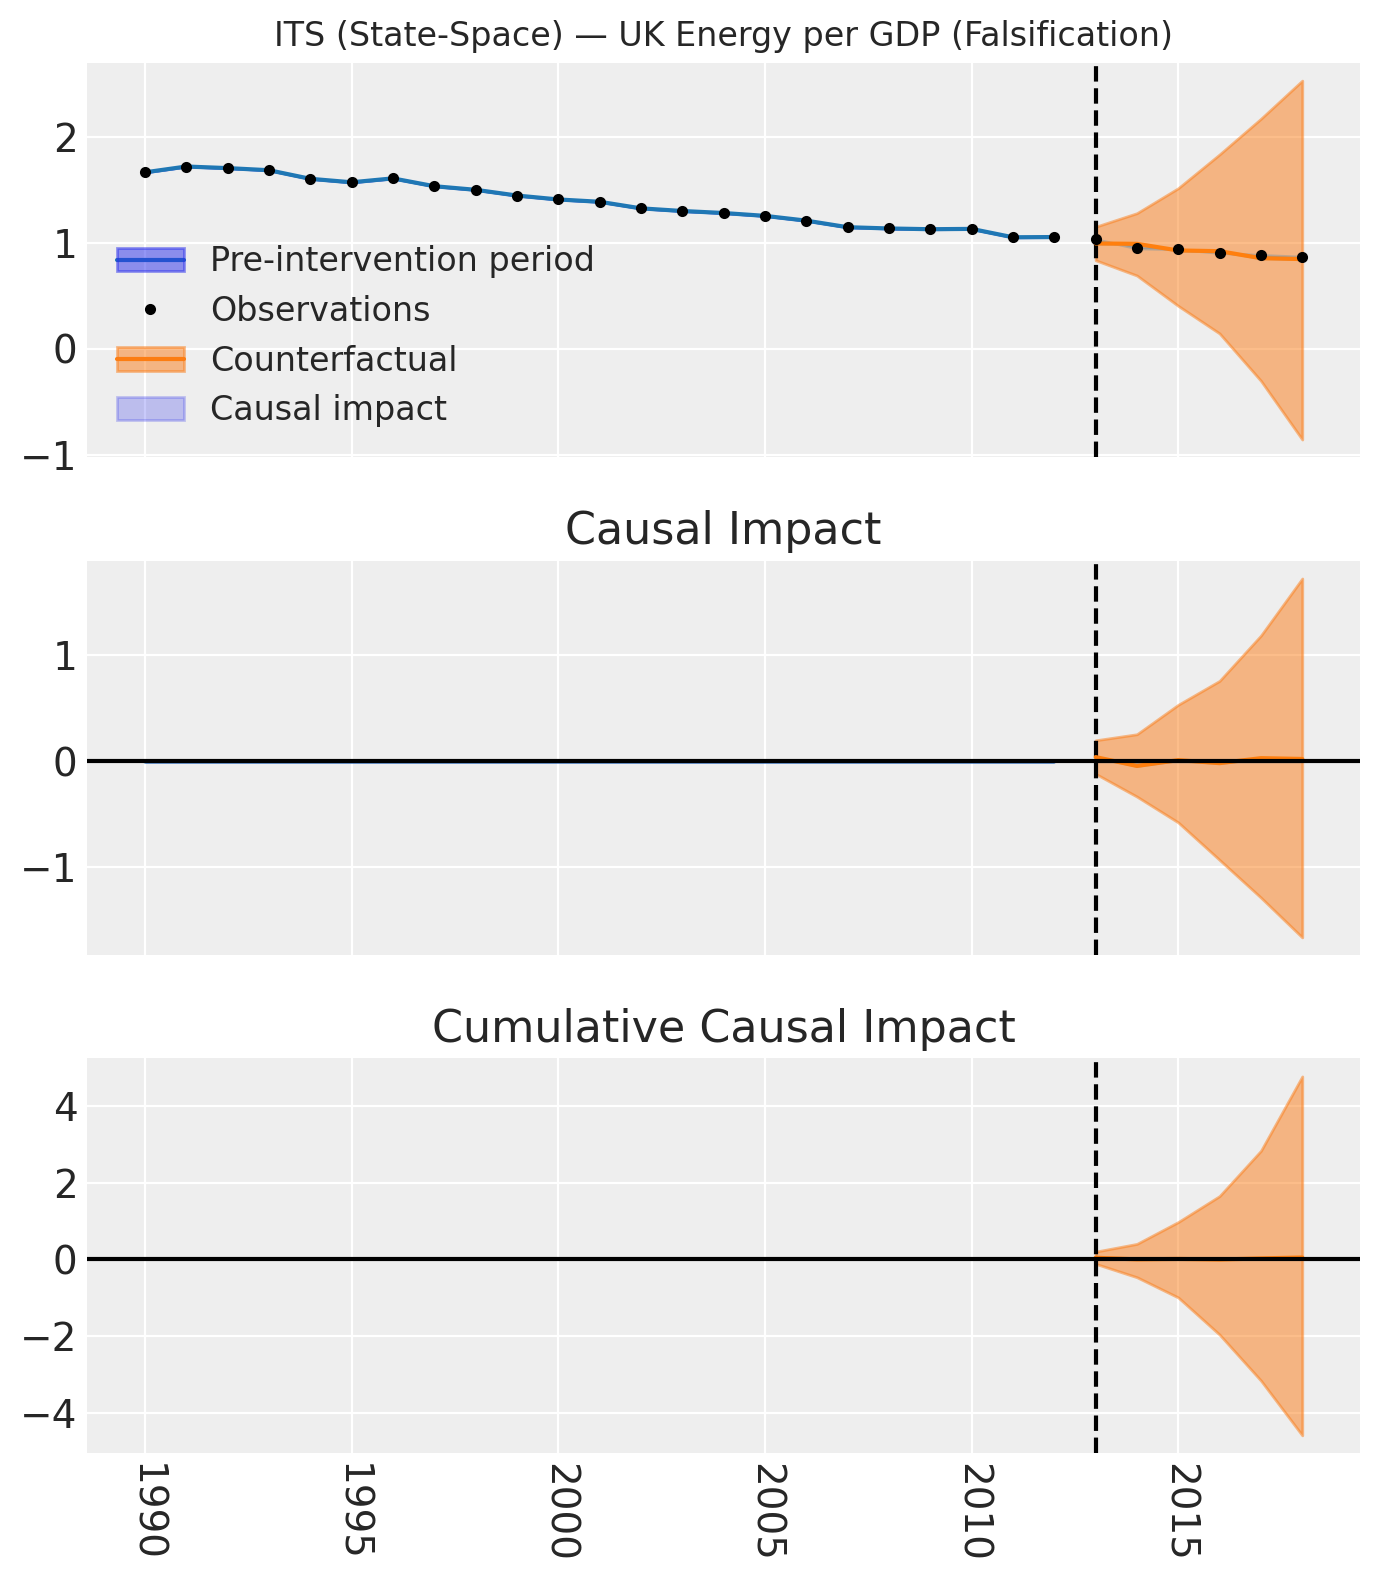

In [ ]:
fig, axes = result_epc.plot(show=False)
axes[0].set_title("ITS (State-Space) — UK Energy per GDP (Falsification)")
plt.tight_layout()
plt.show()

Energy per GDP shows no meaningful break at 2013. The actual trajectory hugs the counterfactual. People kept generating roughly the same amount of economic output per unit of energy; they just stopped getting that energy from coal.

## Assembling the case

We did not prove that the Carbon Price Floor caused the decline in coal CO₂. Proof is not available in observational data. What we did is accumulate four pieces of evidence, each small, each pointing in the same direction:

| Step | What we found | Placebo verdict | What it rules out |
|:-----|:--------------|:----------------|:------------------|
| **Coal CO₂ collapsed** | Large negative effect (~-416 MtCO₂), but a wide structural null | NOT SUPPORTED ($p_{\text{cal}} \approx 0.84$) on its own | Pure random fluctuation, but not yet structural noise — needs corroboration |
| **Gas CO₂ rose** | Clear substitution toward gas (~+192 MtCO₂, tighter null) | SUPPORTED ($p_{\text{cal}} \approx 0.99$) | A general decline in all fuels, or coal being explained by something other than substitution |
| **Total CO₂ effect is weaker** | Small effect absorbed by the null | NOT SUPPORTED (and that's the prediction) | Data error or recession that would push *all* CO₂ down equally |
| **Energy demand stayed flat** | No break in `energy_per_gdp` at 2013 | (qualitative) | Recession or demand shock |

No single finding is conclusive, and the coal-CO₂ placebo, taken alone, does not even clear the 0.95 SUPPORTED bar. That is the point. The four pieces together tell a coherent story the individual checks cannot tell: the Carbon Price Floor made coal uncompetitive, energy producers switched to gas (SUPPORTED), coal CO₂ collapsed (large effect but inside a wide structural null), total CO₂ fell modestly (consistent with substitution rather than elimination), and energy demand was unaffected (no recession). Each line in the table closes off a different alternative explanation; the case is the pile, not any one entry.

:::{.callout-important}
## The epistemological lesson

A credible interval that excludes zero is necessary but not sufficient. The real question is not "is the effect different from zero?" but "is the effect different from what the model would report even if nothing happened?"  Placebo-in-Time (Bugaev & Trujillo, 2026) gives you a calibrated answer to that second question.

And even a calibrated estimate is not enough on its own. You need to trace the mechanism, check the boundaries, and ask whether the story holds from multiple angles.  Gallea (2026) calls this thinking like a detective.  We call it responsible causal inference.

In ITS settings in particular, placebo-in-time turns the unfalsifiable assumption *'the pre-trend would have continued, undisturbed'* into something you can actually probe with the data you already have: by repeatedly asking the model what it would have claimed if nothing had happened, you build an empirical floor for what counts as evidence. It does not give you certainty, but it makes ITS-based causal claims meaningfully more robust, and easier to defend to a skeptical reader.
:::

:::{.callout-tip}
## Three questions for your next case

The case for the Carbon Price Floor came together because we asked four questions in a particular order: estimate, calibrate, trace the mechanism, check the boundary. The same shape works elsewhere. Before you sign off on the next causal claim that crosses your desk, including your own, see if it answers these three:

1. **What does this estimator report when nothing happened?** If you cannot run that check empirically, your credible interval is doing only half the work.
2. **Where should the energy go?** What other outcomes does the *mechanism* predict will move? Falsify on those before you celebrate.
3. **What would unmake this story?** Name the outcome whose movement would falsify the claim, then go look at it.

A causal claim that survives all three lands very differently from one that survives none. Build the pile.
:::
